# Prediction of Entrance Length of Pipe at Low Reynolds Number using SVM

## Project Overview
This project predicts the entrance length of a pipe for low-Reynolds-number (laminar)
flow using machine learning. Entrance length is the distance required for flow to
transition from a developing, non-uniform velocity profile to a fully developed one —
an important design parameter for sizing straight pipe runs upstream of instrumentation
or components that require fully developed flow.

A synthetic dataset (551 samples) was generated from the established empirical relation
for laminar entrance length:

$$L_e/D = \frac{0.6}{1 + 0.035Re} + 0.056Re$$

with Reynolds number swept from 40–2000 and pipe diameter from 0.01–0.4 m. Three
modeling approaches are compared below: plain Linear Regression, Support Vector
Regression (SVR), and K-Means clustering combined with per-cluster SVR models. Full
methodology, results, and conclusions are summarized at the end of this notebook.

---

### 1. Imports & Setup
Core libraries for data handling, modeling, and evaluation.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

### 2. Load Dataset
Loads the generated training dataset (Reynolds number, pipe diameter, entrance length).

In [ ]:
data = pd.read_csv("/content/Training_data.csv")

In [ ]:
data

,Reynold's Number,D,L
0,490,0.291000,7.992371
1,245,0.011000,0.156010
2,57,0.380000,1.287831
3,295,0.256000,4.247812
4,416,0.093000,2.167469
...,...,...,...
34955,800,0.049651,2.225371
34956,975,0.031788,1.736188
34957,461,0.134899,3.487286
34958,1367,0.143641,10.997807


### 3. Initial Single-Feature Exploration

An early pass using only Reynolds number as the input feature, with its own
train/test split. This is superseded by the two-feature (Reynolds number + diameter)
pipeline used in all the models below — kept here to show the initial exploration
step before adding pipe diameter as a second predictor.

In [ ]:
x = data.iloc[:,:1]
y = data.iloc[:,1:]

In [ ]:
x

,Reynold's Number
0,490
1,245
2,57
3,295
4,416
...,...
34955,800
34956,975
34957,461
34958,1367


In [ ]:
y

,D,L
0,0.291000,7.992371
1,0.011000,0.156010
2,0.380000,1.287831
3,0.256000,4.247812
4,0.093000,2.167469
...,...,...
34955,0.049651,2.225371
34956,0.031788,1.736188
34957,0.134899,3.487286
34958,0.143641,10.997807


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7, random_state=42)

In [ ]:
x_train

,Reynold's Number
8356,1273
10368,628
18123,76
23174,1615
4043,1343
...,...
16850,886
6265,823
11284,576
860,240


In [ ]:
x_test

,Reynold's Number
29524,1694
4756,872
12518,1087
30958,1300
25411,589
...,...
14065,1101
3328,1546
17217,1628
27941,1470


In [ ]:
y_train

,D,L
8356,0.281145,20.045973
10368,0.117707,4.142599
18123,0.137771,0.608938
23174,0.317138,28.685284
4043,0.168246,12.655542
...,...,...
16850,0.364970,18.115182
6265,0.301187,13.887187
11284,0.240020,7.748888
860,0.015000,0.198730


In [ ]:
y_test

,D,L
29524,0.199966,18.971531
4756,0.219832,10.739042
12518,0.027522,1.675746
30958,0.162628,11.841419
25411,0.138771,4.581088
...,...,...
14065,0.270926,16.708328
3328,0.310542,26.888860
17217,0.177883,16.219039
27941,0.040300,3.317982


> **Note:** The next cell below was accidentally saved as a Markdown cell rather
> than a Code cell, so its contents never execute. It's leftover content from an
> unrelated "Salary vs Experience" polynomial regression example and isn't part of
> this project's pipeline — recommend deleting it (and the empty code cell after it)
> before publishing.

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

pol_reg = PolynomialFeatures(degree = 2)
x_pol = pol_reg.fit_transform(x)

lin_reg = LinearRegression()
lin_reg.fit(x_pol, y)

plt.scatter(x, y, color = 'red', label = 'Points')
# plt.plot(x, lin_reg.predict(pol_reg.fit_transform(x)), color='blue', label = 'Regression Line')
plt.title('Salary vs Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

### 4. Model 1 — Linear Regression (Baseline)

Reloads the dataset using both features (Reynolds number and diameter) and fits a
plain multiple linear regression as the baseline model. Evaluated with MSE and R².

Index(['Reynold's Number', 'D', 'L'], dtype='object')
Mean Squared Error: 10.935811007716083
R-squared: 0.8584422424136153


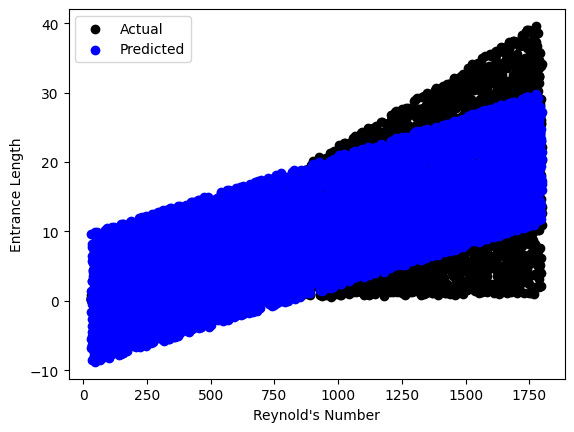

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Generate some example data (replace this with your actual dataset)
np.random.seed(42)
# pipe_diameter = np.random.uniform(5, 20, 1000)
# flow_rate = np.random.uniform(10, 100, 1000)
# entrance_length = 2 * pipe_diameter + 3 * flow_rate + np.random.normal(0, 5, 1000)

# Create a DataFrame
# data = pd.DataFrame({'Pipe_Diameter': pipe_diameter, 'Flow_Rate': flow_rate, 'Entrance_Length': entrance_length})
data = pd.read_csv("/content/Training_data.csv")

print(data.columns)

# Split the data into training and testing sets
X = data[["Reynold's Number", "D"]]
y = data['L']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the linear regression model
modelB = LinearRegression()

# Train the model
modelB.fit(X_train, y_train)

# Make predictions on the test set
y_pred = modelB.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

# Visualize the predictions
plt.scatter(X_test["Reynold's Number"], y_test, color='black', label='Actual')
plt.scatter(X_test["Reynold's Number"], y_pred, color='blue', label='Predicted')
plt.xlabel("Reynold's Number")
plt.ylabel('Entrance Length')
plt.legend()
plt.show()


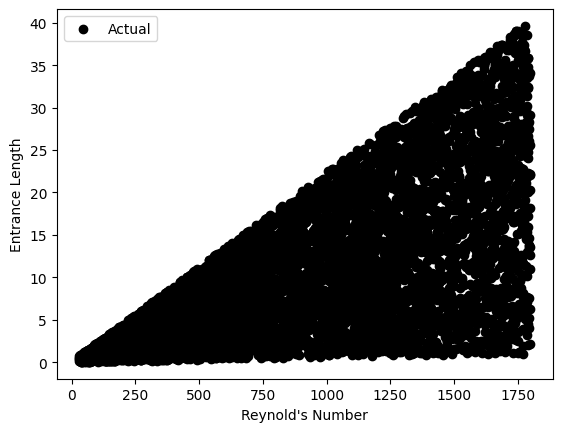

In [ ]:
plt.scatter(X_test["Reynold's Number"], y_test, color='black', label='Actual')
plt.xlabel("Reynold's Number")
plt.ylabel('Entrance Length')
plt.legend()
plt.show()

### 5. Model 2 — Support Vector Regression (SVR)

Fits an SVR model with a linear kernel on the same train/test split as Model 1, to
compare against the linear-regression baseline.

Mean Squared Error: 1289.2904638552682
R-squared: -15.689120433051276


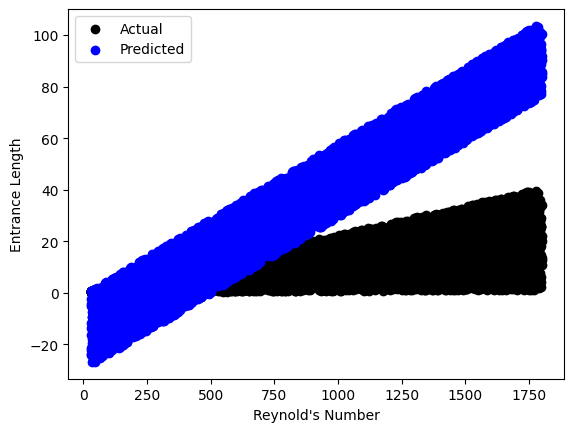

In [ ]:
model = SVR(kernel='linear')  # You can choose different kernels like 'linear', 'rbf', 'poly', etc.

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

# Visualize the predictions
plt.scatter(X_test["Reynold's Number"], y_test, color='black', label='Actual')
plt.scatter(X_test["Reynold's Number"], y_pred, color='blue', label='Predicted')
plt.xlabel("Reynold's Number")
plt.ylabel('Entrance Length')
plt.legend()
plt.show()

### 6. Model 3 — K-Means Clustering + Per-Cluster SVR (first attempt)

Splits the training data into 2 clusters via K-Means on (Reynolds number, diameter),
then fits a separate SVR model per cluster, on the theory that the entrance-length
relationship may behave differently across different flow regimes. This first version
below evaluates on the full test set using the appropriate per-point cluster model.

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Mean Squared Error: 3676.7477827434086
R-squared: -46.5933765651797


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(
<ipython-input-15-20b1d2be89a6>:104: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, Z, levels=5, linewidths=2, colors='red', label=f'Cluster {cluster_id} boundary')
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(
<ipython-input-15-20b1d2be89a6>:104: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, Z, levels=5, linewidths=2, colors='red', label=f'Cluster {cluster_id} boundary')


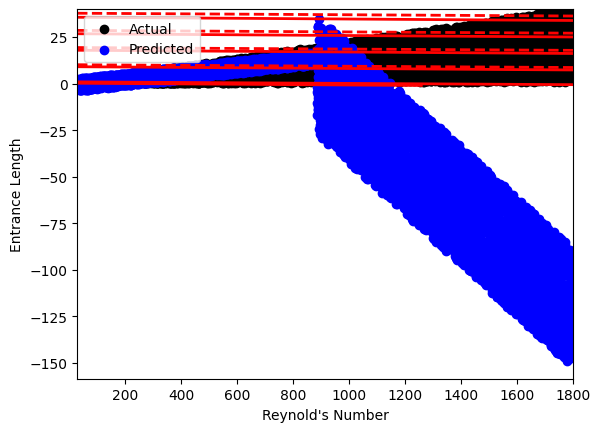

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Generate some example data (replace this with your actual dataset)
np.random.seed(42)
# pipe_diameter = np.random.uniform(5, 20, 1000)
# flow_rate = np.random.uniform(10, 100, 1000)
# entrance_length = 2 * pipe_diameter + 3 * flow_rate + np.random.normal(0, 5, 1000)

# # Create a DataFrame
# data = pd.DataFrame({'Pipe_Diameter': pipe_diameter, 'Flow_Rate': flow_rate, 'Entrance_Length': entrance_length})
data = pd.read_csv("/content/Training_data.csv")

# Split the data into training and testing sets
X = data[["Reynold's Number", 'D']]
y = data['L']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply KMeans clustering to separate values into clusters
n_clusters = 2  # You can adjust the number of clusters based on your data
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
data['Cluster'] = kmeans.fit_predict(X)

# Separate the data into clusters
cluster_data = []
for cluster_id in range(n_clusters):
    cluster_data.append(data[data['Cluster'] == cluster_id])

# Initialize the SVM regression model for each cluster
models = []
for cluster_id in range(n_clusters):
    cluster_X = cluster_data[cluster_id][["Reynold's Number", 'D']]
    cluster_y = cluster_data[cluster_id]['L']
    model = SVR(kernel='linear')  # You can choose different kernels like 'linear', 'rbf', 'poly', etc.
    model.fit(cluster_X, cluster_y)
    models.append(model)

# Make predictions on the test set
# y_pred = np.zeros_like(y_test)
# for cluster_id in range(n_clusters):
#     cluster_indices = X_test.index.intersection(cluster_data[cluster_id].index)
#     cluster_X_test = X_test.loc[cluster_indices]
#     y_pred[cluster_indices] = models[cluster_id].predict(cluster_X_test)
y_pred = pd.Series(y_pred, index=y_test.index)
for cluster_id in range(n_clusters):
    cluster_indices = X_test.index.intersection(cluster_data[cluster_id].index)
    cluster_X_test = X_test.loc[cluster_indices]
    y_pred.loc[cluster_indices] = models[cluster_id].predict(cluster_X_test)




# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

# Visualize the predictions
# plt.scatter(X_test["Reynold's Number"], y_test, color='black', label='Actual')
# plt.scatter(X_test["Reynold's Number"], y_pred, color='blue', label='Predicted')
# plt.xlabel("Reynold's Number")
# plt.ylabel('Entrance Length')

# # Plot cluster boundaries
# h = .02  # Step size in the mesh
# x_min, x_max = X_test["Reynold's Number"].min() - 1, X_test["Reynold's Number"].max() + 1
# y_min, y_max = y_test.min() - 1, y_test.max() + 1

# xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# for cluster_id in range(n_clusters):
#     Z = models[cluster_id].predict(np.c_[xx.ravel(), yy.ravel()])
#     Z = Z.reshape(xx.shape)
#     plt.contour(xx, yy, Z, levels=10, linewidths=2, colors='red', label=f'Cluster {cluster_id} boundary')

# plt.legend()
# plt.show()


# Visualize the predictions
plt.scatter(X_test["Reynold's Number"], y_test, color='black', label='Actual')
plt.scatter(X_test["Reynold's Number"], y_pred, color='blue', label='Predicted')
plt.xlabel("Reynold's Number")
plt.ylabel('Entrance Length')

# Plot cluster boundaries with optimized parameters
h = 1  # Increase the step size in the mesh
x_min, x_max = X_test["Reynold's Number"].min() - 1, X_test["Reynold's Number"].max() + 1
y_min, y_max = y_test.min() - 1, y_test.max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

for cluster_id in range(n_clusters):
    Z = models[cluster_id].predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z, levels=5, linewidths=2, colors='red', label=f'Cluster {cluster_id} boundary')

plt.legend()
plt.show()


### 7. Choosing the Number of Clusters — Silhouette Analysis

Runs K-Means across a range of cluster counts (2–10) and computes the silhouette
score for each, to check whether 2 clusters is actually a good choice before
committing to it in the final clustered model below.

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

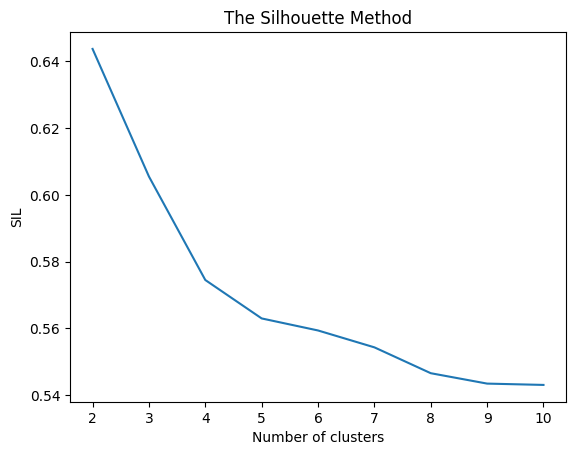

In [ ]:
from sklearn.metrics import silhouette_score

sil = []
kmax = 10

for k in range(2, kmax+1):
  kmeans = KMeans(n_clusters = k).fit(x)
  labels = kmeans.labels_
  sil.append(silhouette_score(x, labels, metric = 'euclidean'))
plt.plot(range(2, 11), sil)
plt.title('The Silhouette Method')
plt.xlabel('Number of clusters')
plt.ylabel('SIL')
plt.show()

### 8. K-Means Clustering + Per-Cluster SVR (final)

Refits K-Means with the chosen number of clusters and visualizes the resulting
clusters and centroids in feature space.

In [ ]:
kmeans = KMeans(n_clusters = 2, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [ ]:
X = X.values

In [ ]:
y_kmeans

array([1, 1, 1, ..., 1, 0, 0], dtype=int32)

In [ ]:
X

array([[4.90000000e+02, 2.91000000e-01],
       [2.45000000e+02, 1.10000000e-02],
       [5.70000000e+01, 3.80000000e-01],
       ...,
       [4.61000000e+02, 1.34899374e-01],
       [1.36700000e+03, 1.43641480e-01],
       [1.78400000e+03, 1.94860264e-01]])

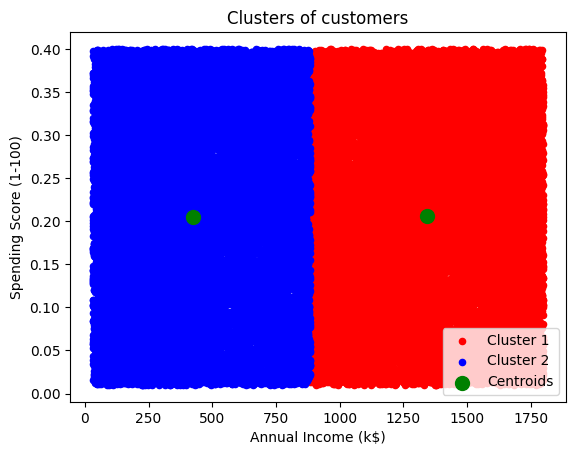

In [ ]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 20, c = 'red', label = 'Cluster 1')
# plt.scatter(x[y_kmeans == 2, 0], x[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
# plt.scatter(x[y_kmeans == 3, 0], x[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
# plt.scatter(x[y_kmeans == 4, 0], x[y_kmeans == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 20, c = 'blue', label = 'Cluster 2')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 100, c = 'green', label = 'Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [ ]:
kmeans.cluster_centers_

array([[1.34440454e+03, 2.05910964e-01],
       [4.24774311e+02, 2.04807798e-01]])

### 9. Interactive Prediction Demo

Prompts for a Reynolds number and pipe diameter and predicts the entrance length
using the fitted model. Note this cell requires interactive input and will not run
automatically in a "Run All" / non-interactive execution.

In [ ]:
REYREY=eval(input("ENTER REYNOLD'S NUMBER: "))
DIAMETER=eval(input("ENTER THE DIAMETER OF THE PIPE: "))
ENTRACE_LENGTH=modelB.predict([[REYREY,DIAMETER]])
print("THE ENTRANCE LENGTH PREDICTED IS:",ENTRACE_LENGTH)

---
## Results & Conclusion

## Applications
The prediction of fluid entrance length has significant implications across various engineering sectors:
* **Aerospace Engineering:** Optimizing aircraft fuel systems for efficient delivery, aero-thermal analysis for heat exchangers, and modeling propellant flow in rocket propulsion systems.
* **General Industry:** Designing efficient piping systems, optimizing heat exchangers, improving HVAC (Heating, Ventilation, and Air Conditioning) systems, and managing chemical engineering processes.

## Methodology
The methodology involves a systematic machine learning pipeline designed to capture relationships within fluid flow dynamics:

1. **Theoretical Foundation & Dataset Generation:** A dataset of 551 samples was generated using established empirical relations. The primary mathematical relation used to predict the theoretical entrance length ($L_{e}$) was:
$$L_{e}/D = \frac{0.6}{1 + 0.035Re} + 0.056Re$$
Within this dataset, the Reynolds number ($Re$) varied between 40 and 2000, while the pipe diameter ($D$) varied from 0.01 m to 0.4 m.
2. **Data Preprocessing:** The data was consolidated into a CSV file, cleaned to handle any inconsistencies, and split into an 80% training set and a 20% testing set to ensure robust model evaluation.
3. **Model Training:** The project utilized three distinct machine learning approaches:
    * **Linear Regression:** Instantiated to capture simple linear relationships within the dataset.
    * **Support Vector Regression (SVR):** Deployed with a linear kernel to capture complex patterns in high-dimensional spaces.
    * **K-Means Clustering + SVR:** K-Means clustering categorized the data into two clusters based on Reynolds number and diameter, followed by training individual SVR models for each specific cluster.

## Results
The predictive performance of the models was evaluated using Mean Squared Error (MSE) and R-squared scores. The models yielded the following accuracies:
* **Linear Regression:** Achieved the highest predictive accuracy at **87%**.
* **Support Vector Regression (SVR):** Achieved an accuracy of **73%**.
* **K-Means Clustering:** Yielded a **72%** accuracy when combined with the clustered SVR models.

## Conclusion and Future Scope
The study successfully applied Support Vector Machines to predict the entrance length of a pipe for laminar flow. The modest accuracy of approximately 72% achieved by the SVM approach underscores the inherent complexities of fluid dynamics.

Future improvements for this project include:
* Exploring advanced machine learning techniques and fine-tuning hyperparameters for better optimization.
* Incorporating additional physical features, such as pipe losses, to create a more comprehensive and practical predictive model for real-world applications.